# Đồ án 05 – Giọng điệu văn bản báo cáo và phản ứng thị trường (Mỹ + Việt Nam)
Notebook chạy **từ dữ liệu đã xử lý** (`data/<thị trường>/processed/`). Muốn tải lại từ đầu: `python run_all.py --market both`.

**Câu hỏi:** giọng điệu (tone) của 10-K / Thông điệp của ban lãnh đạo có tác động tích cực hay tiêu cực lên CAR[T, T+3] không – văn bản có mang thông tin cho thị trường không?

In [1]:
import sys, os, pathlib, pandas as pd
from IPython.display import display, Image, Markdown
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src')); os.chdir(ROOT)
from analysis import a01_tone, a02_event, a03_regress, a04_figures, a06_summary
MARKETS = [m for m in ['us', 'vn'] if (ROOT / 'data' / m / 'processed' / 'docs.csv').exists()]
MARKETS

['us', 'vn']

## 1. Chạy lại phần phân tích (tone → sự kiện → hồi quy → hình)

In [2]:
for m in MARKETS:
    txt = ROOT / 'data' / m / 'interim' / 'text'
    # a01 cần văn bản đã trích (data/<mkt>/interim) và từ điển. Từ điển LM (Mỹ) không có trong git vì giấy phép:
    # thiếu thì bỏ qua a01 và dùng tone_panel.csv đã commit trong data/<mkt>/processed.
    has_dict = m == 'vn' or any((ROOT / 'dict').glob('Loughran*MasterDictionary*.csv'))
    steps = ([a01_tone] if txt.exists() and any(txt.iterdir()) and has_dict else []) + [a02_event, a03_regress, a04_figures, a06_summary]
    print(m, '→', [s.__name__.split('.')[-1] for s in steps])
    for step in steps:
        step.main(m)

us → ['a01_tone', 'a02_event', 'a03_regress', 'a04_figures', 'a06_summary']


Tone us:   0%|          | 0/500 [00:00<?, ?it/s]

Tone us:   0%|          | 2/500 [00:00<00:28, 17.30it/s]

Tone us:   1%|          | 4/500 [00:00<00:31, 15.61it/s]

Tone us:   1%|          | 6/500 [00:00<00:35, 14.09it/s]

...

Tone vn: 100%|██████████| 605/605 [00:10<00:00, 56.27it/s]

               count    mean     std     min     25%     50%     75%     max
fin_neg        605.0  0.0059  0.0050  0.0000  0.0019  0.0048  0.0087  0.0212
fin_pos        605.0  0.0333  0.0103  0.0137  0.0262  0.0323  0.0397  0.0621
fin_unc        605.0  0.0028  0.0025  0.0000  0.0010  0.0024  0.0040  0.0114
fin_lit        605.0  0.0000  0.0001  0.0000  0.0000  0.0000  0.0000  0.0008
fin_net        605.0  0.7025  0.2392  0.0588  0.5500  0.7500  0.9000  1.0000
gen_neg        605.0  0.0211  0.0071  0.0067  0.0164  0.0210  0.0254  0.0389
gen_pos        605.0  0.0563  0.0120  0.0321  0.0475  0.0556  0.0644  0.0867
gen_unc        605.0  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
gen_lit        605.0  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
gen_net        605.0  0.4505  0.1732  0.0272  0.3333  0.4500  0.5641  0.8296
fin_neg_tfidf  605.0  1.1745  1.1598  0.0000  0.2590  0.8852  1.7368  5.0781
gen_neg_tfidf  605.0  2.5504  1.6683  0.0112  1.3393  2.2005  3.4735  8.3067

508 sự kiện
                    window   N  mean_pct  median_pct       t    p_t  p_wilcoxon  pct_positive  p_sign   t_BMP
                 CAR[0,3] 505   -0.3288     -0.2564 -1.5629 0.1187      0.0706       46.3366  0.1091 -1.1198
 CAR market-adjusted[0,3] 505   -0.1640     -0.3488 -0.7834 0.4338      0.2527       46.5347  0.1302     NaN
                 CAR[0,1] 507   -0.1165     -0.2181 -0.8171 0.4142      0.0719       45.1677  0.0329 -0.7845
 CAR market-adjusted[0,1] 507   -0.0133     -0.2334 -0.0952 0.9242      0.2060       45.3649  0.0410     NaN
                CAR[-1,1] 505   -0.0999     -0.2130 -0.5823 0.5606      0.2639       45.9406  0.0750 -0.5789
CAR market-adjusted[-1,1] 505    0.0021     -0.0939  0.0131 0.9895      0.5788       47.9208  0.3735     NaN
                 CAR[0,5] 505   -0.7553     -0.7303 -3.0165 0.0027      0.0006       44.1584  0.0098 -2.3087
 CAR market-adjusted[0,5] 505   -0.5856     -0.5540 -2.3291 0.0202      0.0071       44.7525  0.0206     NaN
      

                           M1 nền        M2 fin_neg        M3 gen_neg        M4 đối đầu        M5 net+unc         M6 tf-idf
Intercept         0.0551 (0.0521)   0.0565 (0.0513)   0.0530 (0.0534)   0.0570 (0.0523)   0.0538 (0.0518)   0.0530 (0.0538)
log_tradeval     -0.0030 (0.0023)  -0.0030 (0.0022)  -0.0030 (0.0022)  -0.0031 (0.0022)  -0.0031 (0.0022)  -0.0030 (0.0023)
pre_ret          -0.0319 (0.0205)  -0.0326 (0.0205)  -0.0318 (0.0204)  -0.0326 (0.0204)  -0.0336 (0.0206)  -0.0322 (0.0205)
log_len          -0.0010 (0.0055)  -0.0012 (0.0054)  -0.0008 (0.0058)  -0.0012 (0.0057)  -0.0007 (0.0055)  -0.0007 (0.0060)
vn30              0.0004 (0.0055)   0.0004 (0.0054)   0.0005 (0.0055)   0.0004 (0.0054)   0.0000 (0.0055)   0.0004 (0.0054)
beta              0.0019 (0.0064)   0.0020 (0.0064)   0.0020 (0.0065)   0.0020 (0.0065)   0.0025 (0.0063)   0.0019 (0.0064)
N                             505               505               505               505               505               505
Adj. R2 

                                         buoc  so_van_ban
                              Mã VN30 + VN100         100
    Mã–năm có BCTN PDF trên CafeF (2016–2025)         813
     Tìm được Thông điệp HĐQT (ok + too_long)         605
               không tìm thấy thư (not_found)         195
       thư quá ngắn < 250 âm tiết (too_short)           0
     Có ngày sự kiện T=0 (PDF ModDate hợp lệ)         537
Có CAR (đủ dữ liệu giá, ≥ 80 phiên ước lượng)         508
                                  Có CAR[0,3]         505
           Vào hồi quy M2 (đủ biến kiểm soát)         505


## Kết quả: Mỹ – 10-K

**Mục tiêu 1 – thống kê tone**

,count,mean,std,min,25%,50%,75%,max
fin_neg,500.0,0.0191,0.0049,0.0083,0.0158,0.0193,0.0224,0.0323
fin_pos,500.0,0.0059,0.0017,0.0029,0.0048,0.0056,0.0067,0.0111
fin_unc,500.0,0.0161,0.0033,0.0084,0.0139,0.0157,0.0184,0.0239
fin_lit,500.0,0.0130,0.0043,0.0061,0.0099,0.0120,0.0160,0.0245
fin_net,500.0,-0.5193,0.1379,-0.7671,-0.6125,-0.5431,-0.4438,-0.1030
gen_neg,500.0,0.0276,0.0038,0.0173,0.0255,0.0275,0.0303,0.0353
gen_pos,500.0,0.0612,0.0071,0.0483,0.0560,0.0609,0.0661,0.0798
gen_unc,500.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
gen_lit,500.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
gen_net,500.0,0.3771,0.0787,0.2140,0.3246,0.3735,0.4199,0.6054


**Mục tiêu 2 – từ điển tổng quát gán sai**

```
Số văn bản: 500
Tỷ lệ 'nhiễu' của từ điển tổng quát (tần suất từ tiêu cực tổng quát không nằm trong danh sách tiêu cực tài chính): 73.9%

Tương quan:
         fin_neg  gen_neg  fin_net  gen_net
fin_neg    1.000    0.566   -0.646   -0.455
gen_neg    0.566    1.000   -0.394   -0.787
fin_net   -0.646   -0.394    1.000    0.332
gen_net   -0.455   -0.787    0.332    1.000

```

,word,freq,in_fin_negative,share_pct,nghia_trong_tai_chinh
0,TAX,88271,False,10.94,NaN
1,COST,45990,False,5.70,NaN
2,CAPITAL,43788,False,5.43,NaN
3,LOSS,41928,True,5.20,NaN
4,FOREIGN,38289,False,4.75,NaN
5,EXPENSE,37150,False,4.61,NaN
6,SERVICE,33140,False,4.11,NaN
7,LIABILITY,19783,False,2.45,NaN
8,LOWER,18302,False,2.27,NaN
9,DECREASE,15538,False,1.93,NaN


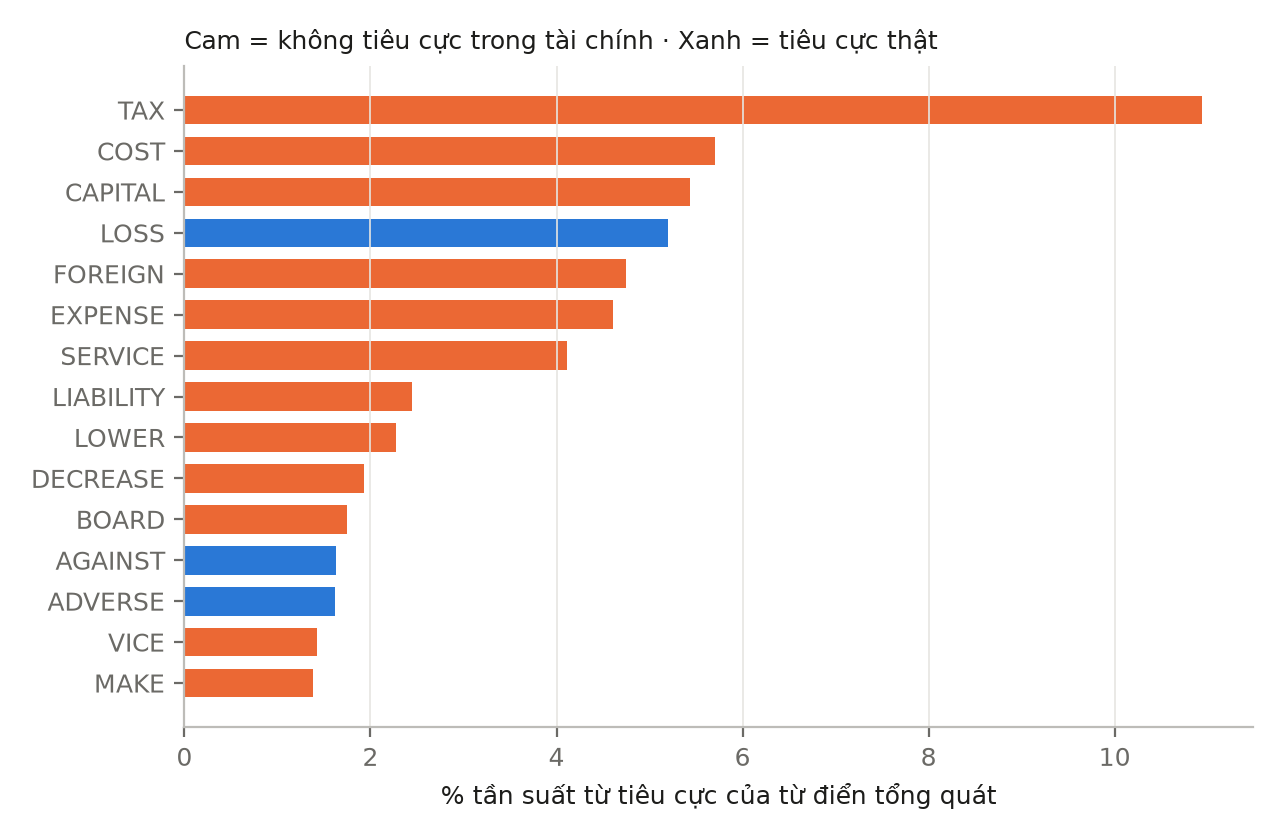

**Mục tiêu 3 – CAR có khác 0 không?**

,window,N,mean_pct,median_pct,t,p_t,p_wilcoxon,pct_positive,p_sign,t_BMP
0,"CAR[0,3]",500,-0.1703,-0.1267,-1.0225,0.3070,0.1880,48.2,0.4471,-0.9928
1,"CAR market-adjusted[0,3]",500,-0.0594,0.0069,-0.3501,0.7264,0.6935,50.2,0.9643,NaN
2,"CAR[0,1]",500,-0.1339,-0.1187,-0.9444,0.3454,0.0399,47.0,0.1946,-0.8339
3,"CAR market-adjusted[0,1]",500,-0.1008,-0.1064,-0.6988,0.4850,0.1413,48.2,0.4471,NaN
4,"CAR[-1,1]",500,0.0528,-0.0794,0.3344,0.7382,0.4362,47.4,0.2635,0.2484
5,"CAR market-adjusted[-1,1]",500,0.1588,0.0182,0.9865,0.3244,0.7495,50.4,0.8933,NaN
6,"CAR[0,5]",500,-0.2225,-0.0379,-1.1744,0.2408,0.3635,49.2,0.7543,-1.2637
7,"CAR market-adjusted[0,5]",500,-0.0519,0.0829,-0.2767,0.7821,0.8661,51.6,0.5024,NaN
8,"CAR[0,10]",500,-0.2310,-0.2210,-0.9953,0.3201,0.2879,47.0,0.1946,-1.4003
9,"CAR market-adjusted[0,10]",500,0.1770,0.1413,0.7430,0.4578,0.4393,51.8,0.4471,NaN


**CAR[0,3] theo nhóm giọng điệu**

,tone_grp,N,mean_pct,p_t
0,T1 Tiêu cực,167.0,-0.0770,0.7911
1,T2 Trung tính,166.0,-0.1289,0.5825
2,T3 Tích cực,167.0,-0.2627,0.1973
3,T3 − T1,334.0,-0.1857,0.6004


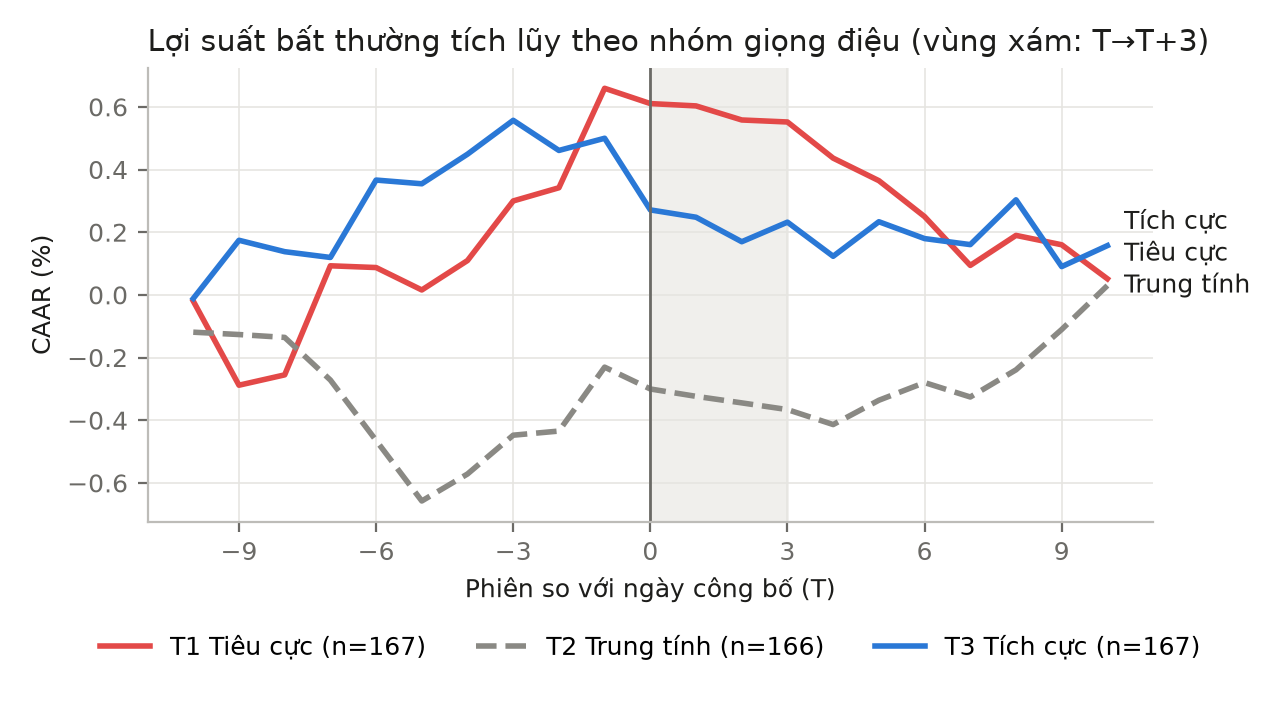

**regression_main**

,Unnamed: 0,M1 nền,M2 fin_neg,M3 gen_neg,M4 đối đầu,M5 net+unc,M6 tf-idf,M7 MD&A,M8 FinBERT
0,Intercept,0.0030 (0.0550),-0.0022 (0.0529),0.0243 (0.0524),0.0116 (0.0504),-0.0035 (0.0571),-0.0177 (0.0764),0.0415 (0.1121),-0.0055 (0.0584)
1,log_mcap,-0.0007 (0.0021),-0.0006 (0.0020),-0.0007 (0.0020),-0.0005 (0.0019),-0.0006 (0.0021),-0.0006 (0.0021),-0.0017 (0.0030),-0.0003 (0.0022)
2,log_bm,-0.0011 (0.0015),-0.0011 (0.0015),-0.0012 (0.0015),-0.0010 (0.0015),-0.0011 (0.0015),-0.0011 (0.0015),-0.0007 (0.0016),-0.0011 (0.0015)
3,log_turn,0.0070 (0.0052),0.0072 (0.0051),0.0072 (0.0051),0.0078 (0.0050),0.0071 (0.0056),0.0072 (0.0051),0.0078 (0.0057),0.0067 (0.0053)
4,pre_alpha,-6.3726* (3.2647),-6.3944** (3.2573),-6.5123** (3.2837),-6.6576** (3.2835),-6.4067** (3.2647),-6.4334** (3.2631),-6.5124* (3.5273),-6.2904* (3.2857)
5,log_len,0.0009 (0.0018),0.0012 (0.0024),-0.0008 (0.0021),-0.0002 (0.0023),0.0013 (0.0024),0.0026 (0.0060),-0.0002 (0.0047),0.0008 (0.0018)
6,N,470,470,470,470,470,470,427,470
7,Adj. R2,0.0193,0.0171,0.0187,0.0174,0.0160,0.0173,0.0112,0.0180
8,fin_neg_z,NaN,-0.0004 (0.0016),NaN,-0.0018 (0.0018),NaN,NaN,NaN,NaN
9,gen_neg_z,NaN,NaN,0.0018 (0.0013),0.0025* (0.0015),NaN,NaN,NaN,NaN


**regression_fama_macbeth**

,Unnamed: 0,fin_neg_z,gen_neg_z,fin_neg_tfidf_z
0,Số kỳ cắt ngang,10,10,10
1,const,-0.0079 (t=-0.12),-0.0148 (t=-0.21),-0.0097 (t=-0.13)
2,fin_neg_tfidf_z,NaN,NaN,-0.0012 (t=-0.64)
3,fin_neg_z,-0.0011 (t=-0.95),NaN,NaN
4,gen_neg_z,NaN,-0.0009 (t=-0.58),NaN
5,log_bm,-0.0022* (t=-1.88),-0.0020 (t=-1.61),-0.0017* (t=-1.86)
6,log_len,0.0021 (t=1.14),0.0020 (t=0.78),0.0027 (t=1.02)
7,log_mcap,-0.0007 (t=-0.35),-0.0003 (t=-0.18),-0.0008 (t=-0.40)
8,log_turn,0.0009 (t=0.13),0.0010 (t=0.14),0.0004 (t=0.05)
9,pre_alpha,-6.6367** (t=-2.33),-5.9482** (t=-2.14),-6.4618** (t=-2.20)


**regression_robustness**

,Unnamed: 0,Market-adjusted,BHAR (LM 2011),Placebo −60 phiên,"CAR[0,1]","CAR[-1,1]","CAR[0,5]","CAR[0,10]"
0,Intercept,0.0051 (0.0603),0.0053 (0.0609),0.0119 (0.0397),-0.0177 (0.0607),-0.0045 (0.0714),0.0396 (0.0616),0.0168 (0.1172)
1,fin_neg_z,0.0006 (0.0018),0.0007 (0.0018),0.0008 (0.0012),0.0003 (0.0014),0.0024 (0.0019),-0.0003 (0.0018),-0.0016 (0.0025)
2,log_mcap,-0.0007 (0.0021),-0.0007 (0.0021),0.0001 (0.0014),0.0006 (0.0022),0.0014 (0.0028),-0.0029 (0.0023),-0.0027 (0.0043)
3,log_bm,-0.0007 (0.0014),-0.0008 (0.0014),0.0019 (0.0016),-0.0008 (0.0015),0.0002 (0.0018),-0.0032* (0.0019),-0.0046* (0.0025)
4,log_turn,0.0076 (0.0049),0.0083 (0.0050),0.0015 (0.0029),0.0037 (0.0052),0.0099 (0.0088),0.0029 (0.0055),0.0071 (0.0077)
5,pre_alpha,-1.5836 (3.3469),-1.7034 (3.4741),1.4691 (1.9671),-4.9445* (2.9047),-7.4451*** (2.8830),-10.1190*** (3.5636),-14.0758*** (4.2330)
6,log_len,0.0009 (0.0028),0.0008 (0.0028),-0.0014 (0.0017),-0.0001 (0.0017),-0.0022 (0.0022),0.0023 (0.0023),0.0033 (0.0033)
7,N,470,470,470,470,470,470,470
8,Adj. R2,-0.0032,-0.0014,0.0263,0.0201,0.0388,0.0307,0.0685


**assumption_tests**

,Unnamed: 0,0
0,Breusch-Pagan p,0.0000
1,Jarque-Bera p,0.0000
2,"corr(fin_neg, gen_neg)",0.5657
3,VIF fin_neg_z,2.8468
4,VIF log_mcap,2.8586
5,VIF log_bm,2.8815
6,VIF log_turn,2.9774
7,VIF pre_alpha,1.3546
8,VIF log_len,2.2514


In [3]:
m = 'us'
if m in MARKETS:
    out = ROOT / 'outputs' / m
    display(Markdown('**Mục tiêu 1 – thống kê tone**'), pd.read_csv(ROOT/'data'/m/'processed'/'tone_panel.csv').filter(regex='^(fin|gen)_').describe().T.round(4))
    display(Markdown('**Mục tiêu 2 – từ điển tổng quát gán sai**'), Markdown('```\n'+(out/'dictionary_comparison.txt').read_text(encoding='utf-8')+'\n```'))
    display(pd.read_csv(out/'misclassified_general_neg.csv').head(15), Image(str(out/'fig2_misclassified.png'), width=560))
    display(Markdown('**Mục tiêu 3 – CAR có khác 0 không?**'), pd.read_csv(out/'car_tests.csv'))
    display(Markdown('**CAR[0,3] theo nhóm giọng điệu**'), pd.read_csv(out/'car_by_tone.csv'), Image(str(out/'fig3_caar_by_tone.png'), width=560))
    for f in ['regression_main', 'regression_fama_macbeth', 'regression_robustness', 'assumption_tests']:
        display(Markdown(f'**{f}**'), pd.read_csv(out/f'{f}.csv'))


## Kết quả: Việt Nam – Thông điệp của ban lãnh đạo

**Mục tiêu 1 – thống kê tone**

,count,mean,std,min,25%,50%,75%,max
fin_neg,605.0,0.0059,0.0050,0.0000,0.0019,0.0048,0.0087,0.0212
fin_pos,605.0,0.0333,0.0103,0.0137,0.0262,0.0323,0.0397,0.0621
fin_unc,605.0,0.0028,0.0025,0.0000,0.0010,0.0024,0.0040,0.0114
fin_lit,605.0,0.0000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0008
fin_net,605.0,0.7025,0.2392,0.0588,0.5500,0.7500,0.9000,1.0000
gen_neg,605.0,0.0211,0.0071,0.0067,0.0164,0.0210,0.0254,0.0389
gen_pos,605.0,0.0563,0.0120,0.0321,0.0475,0.0556,0.0644,0.0867
gen_unc,605.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
gen_lit,605.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
gen_net,605.0,0.4505,0.1732,0.0272,0.3333,0.4500,0.5641,0.8296


**Mục tiêu 2 – từ điển tổng quát gán sai**

```
Số văn bản: 605
Tỷ lệ 'nhiễu' của từ điển tổng quát (tần suất từ tiêu cực tổng quát không nằm trong danh sách tiêu cực tài chính): 92.0%

Tương quan:
         fin_neg  gen_neg  fin_net  gen_net
fin_neg    1.000    0.455   -0.928   -0.400
gen_neg    0.455    1.000   -0.430   -0.863
fin_net   -0.928   -0.430    1.000    0.419
gen_net   -0.400   -0.863    0.419    1.000

```

,word,freq,in_fin_negative,share_pct,nghia_trong_tai_chinh
0,cho,3778,False,25.93,NaN
1,thương,1203,False,8.26,NaN
2,khó khăn,772,True,5.30,NaN
3,bán,766,False,5.26,NaN
4,giảm,683,False,4.69,NaN
5,mạnh mẽ,660,False,4.53,NaN
6,hạn,561,False,3.85,NaN
7,xanh,409,False,2.81,NaN
8,ảnh hưởng,380,False,2.61,NaN
9,thứ,348,False,2.39,NaN


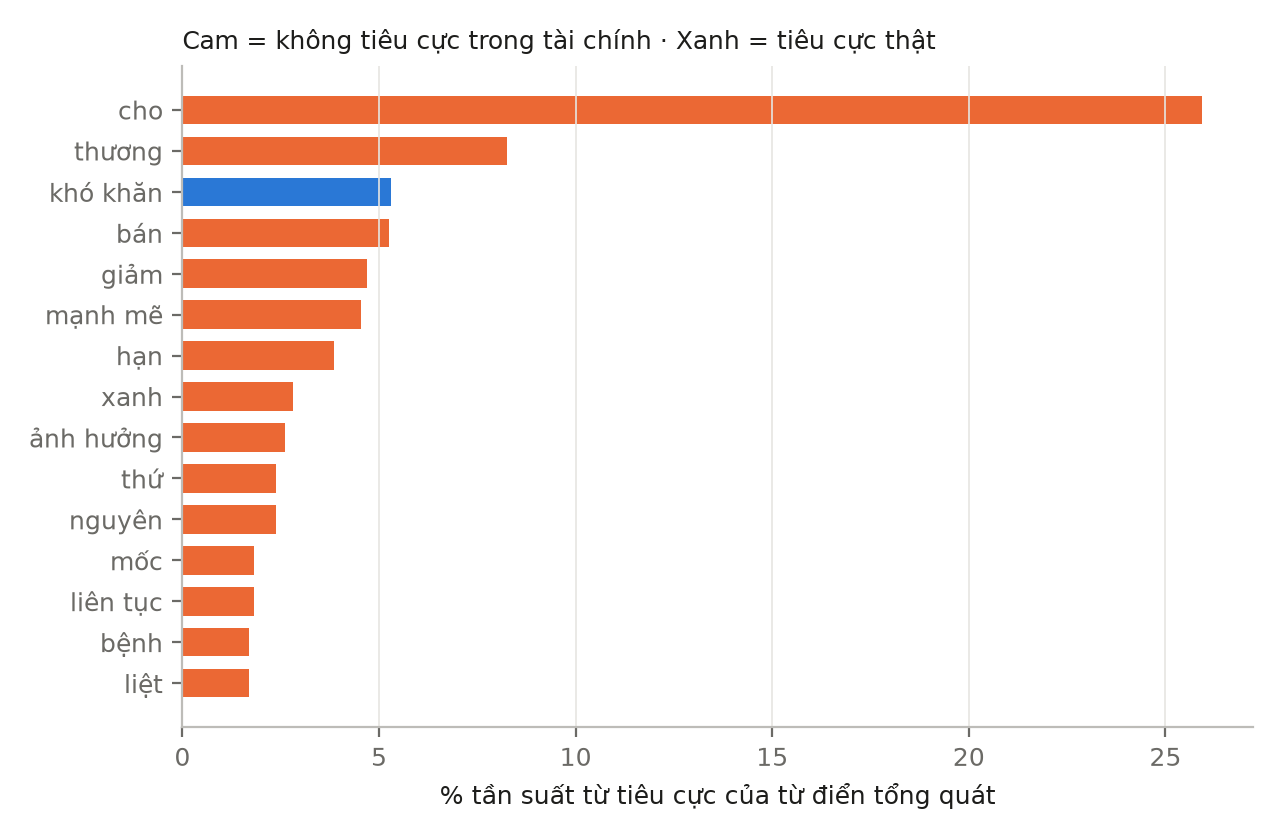

**Mục tiêu 3 – CAR có khác 0 không?**

,window,N,mean_pct,median_pct,t,p_t,p_wilcoxon,pct_positive,p_sign,t_BMP
0,"CAR[0,3]",505,-0.3288,-0.2564,-1.5629,0.1187,0.0706,46.3366,0.1091,-1.1198
1,"CAR market-adjusted[0,3]",505,-0.1640,-0.3488,-0.7834,0.4338,0.2527,46.5347,0.1302,NaN
2,"CAR[0,1]",507,-0.1165,-0.2181,-0.8171,0.4142,0.0719,45.1677,0.0329,-0.7845
3,"CAR market-adjusted[0,1]",507,-0.0133,-0.2334,-0.0952,0.9242,0.2060,45.3649,0.0410,NaN
4,"CAR[-1,1]",505,-0.0999,-0.2130,-0.5823,0.5606,0.2639,45.9406,0.0750,-0.5789
5,"CAR market-adjusted[-1,1]",505,0.0021,-0.0939,0.0131,0.9895,0.5788,47.9208,0.3735,NaN
6,"CAR[0,5]",505,-0.7553,-0.7303,-3.0165,0.0027,0.0006,44.1584,0.0098,-2.3087
7,"CAR market-adjusted[0,5]",505,-0.5856,-0.5540,-2.3291,0.0202,0.0071,44.7525,0.0206,NaN
8,"CAR[0,10]",503,-1.0460,-1.1473,-3.0941,0.0021,0.0004,43.1412,0.0024,-2.4046
9,"CAR market-adjusted[0,10]",503,-0.6720,-0.6948,-2.0001,0.0460,0.0088,44.9304,0.0257,NaN


**CAR[0,3] theo nhóm giọng điệu**

,tone_grp,N,mean_pct,p_t
0,T1 Tiêu cực,168.0,-0.4914,0.1764
1,T2 Trung tính,169.0,-0.4521,0.1548
2,T3 Tích cực,168.0,-0.0927,0.7811
3,T3 − T1,336.0,0.3987,0.4182


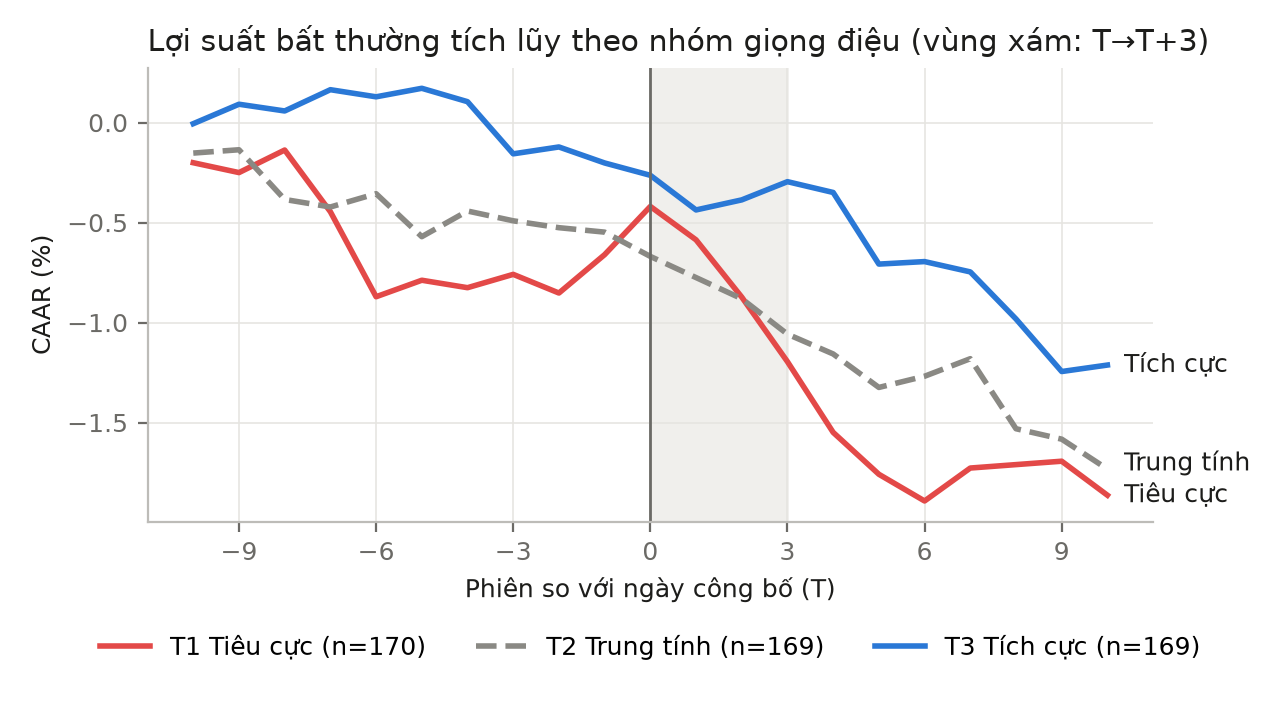

**regression_main**

,Unnamed: 0,M1 nền,M2 fin_neg,M3 gen_neg,M4 đối đầu,M5 net+unc,M6 tf-idf
0,Intercept,0.0551 (0.0521),0.0565 (0.0513),0.0530 (0.0534),0.0570 (0.0523),0.0538 (0.0518),0.0530 (0.0538)
1,log_tradeval,-0.0030 (0.0023),-0.0030 (0.0022),-0.0030 (0.0022),-0.0031 (0.0022),-0.0031 (0.0022),-0.0030 (0.0023)
2,pre_ret,-0.0319 (0.0205),-0.0326 (0.0205),-0.0318 (0.0204),-0.0326 (0.0204),-0.0336 (0.0206),-0.0322 (0.0205)
3,log_len,-0.0010 (0.0055),-0.0012 (0.0054),-0.0008 (0.0058),-0.0012 (0.0057),-0.0007 (0.0055),-0.0007 (0.0060)
4,vn30,0.0004 (0.0055),0.0004 (0.0054),0.0005 (0.0055),0.0004 (0.0054),0.0000 (0.0055),0.0004 (0.0054)
5,beta,0.0019 (0.0064),0.0020 (0.0064),0.0020 (0.0065),0.0020 (0.0065),0.0025 (0.0063),0.0019 (0.0064)
6,N,505,505,505,505,505,505
7,Adj. R2,0.0046,0.0036,0.0027,0.0016,0.0056,0.0027
8,fin_neg_z,NaN,-0.0016 (0.0019),NaN,-0.0017 (0.0022),NaN,NaN
9,gen_neg_z,NaN,NaN,-0.0006 (0.0022),0.0001 (0.0025),NaN,NaN


**regression_fama_macbeth**

,Unnamed: 0,fin_neg_z,gen_neg_z,fin_neg_tfidf_z
0,Số kỳ cắt ngang,10,10,10
1,beta,-0.0029 (t=-0.35),-0.0014 (t=-0.17),-0.0030 (t=-0.38)
2,const,0.0667 (t=1.16),0.0549 (t=0.96),0.0564 (t=0.97)
3,fin_neg_tfidf_z,NaN,NaN,0.0005 (t=0.24)
4,fin_neg_z,-0.0001 (t=-0.06),NaN,NaN
5,gen_neg_z,NaN,-0.0008 (t=-0.39),NaN
6,log_len,-0.0049** (t=-2.50),-0.0036 (t=-1.43),-0.0052 (t=-1.62)
7,log_tradeval,-0.0018 (t=-0.60),-0.0018 (t=-0.59),-0.0011 (t=-0.38)
8,pre_ret,-0.0726*** (t=-3.19),-0.0742*** (t=-3.44),-0.0697*** (t=-3.30)
9,vn30,-0.0051 (t=-0.92),-0.0051 (t=-1.01),-0.0055 (t=-1.01)


**regression_robustness**

,Unnamed: 0,Market-adjusted,BHAR (LM 2011),Placebo −60 phiên,"CAR[0,1]","CAR[-1,1]","CAR[0,5]","CAR[0,10]"
0,Intercept,0.0684 (0.0534),0.0690 (0.0540),-0.0247 (0.0278),0.0556* (0.0335),0.0531 (0.0403),0.1065 (0.0710),0.1400 (0.0953)
1,fin_neg_z,-0.0016 (0.0019),-0.0018 (0.0018),0.0032* (0.0018),0.0012 (0.0014),0.0019 (0.0018),-0.0068*** (0.0024),-0.0048 (0.0031)
2,log_tradeval,-0.0033 (0.0024),-0.0034 (0.0024),0.0038** (0.0015),-0.0028* (0.0016),-0.0020 (0.0018),-0.0053** (0.0025),-0.0089** (0.0037)
3,pre_ret,-0.0091 (0.0215),-0.0101 (0.0207),0.0355* (0.0183),-0.0100 (0.0167),-0.0044 (0.0178),-0.0642** (0.0265),-0.0683* (0.0377)
4,log_len,-0.0007 (0.0056),-0.0006 (0.0056),-0.0008 (0.0032),-0.0012 (0.0032),-0.0024 (0.0040),-0.0032 (0.0078),0.0018 (0.0100)
5,vn30,0.0002 (0.0053),0.0002 (0.0053),-0.0007 (0.0038),0.0020 (0.0039),-0.0012 (0.0043),0.0032 (0.0071),0.0078 (0.0089)
6,beta,-0.0064 (0.0066),-0.0062 (0.0067),-0.0183*** (0.0044),0.0024 (0.0044),0.0044 (0.0049),0.0037 (0.0069),-0.0027 (0.0092)
7,N,505,508,490,507,505,505,503
8,Adj. R2,0.0147,0.0169,0.0537,0.0013,0.0003,0.0332,0.0490


**assumption_tests**

,Unnamed: 0,0
0,Breusch-Pagan p,0.0002
1,Jarque-Bera p,0.0000
2,"corr(fin_neg, gen_neg)",0.4718
3,VIF fin_neg_z,1.2928
4,VIF log_tradeval,2.9662
5,VIF pre_ret,1.0420
6,VIF log_len,1.1179
7,VIF vn30,1.3177
8,VIF beta,1.4394


In [4]:
m = 'vn'
if m in MARKETS:
    out = ROOT / 'outputs' / m
    display(Markdown('**Mục tiêu 1 – thống kê tone**'), pd.read_csv(ROOT/'data'/m/'processed'/'tone_panel.csv').filter(regex='^(fin|gen)_').describe().T.round(4))
    display(Markdown('**Mục tiêu 2 – từ điển tổng quát gán sai**'), Markdown('```\n'+(out/'dictionary_comparison.txt').read_text(encoding='utf-8')+'\n```'))
    display(pd.read_csv(out/'misclassified_general_neg.csv').head(15), Image(str(out/'fig2_misclassified.png'), width=560))
    display(Markdown('**Mục tiêu 3 – CAR có khác 0 không?**'), pd.read_csv(out/'car_tests.csv'))
    display(Markdown('**CAR[0,3] theo nhóm giọng điệu**'), pd.read_csv(out/'car_by_tone.csv'), Image(str(out/'fig3_caar_by_tone.png'), width=560))
    for f in ['regression_main', 'regression_fama_macbeth', 'regression_robustness', 'assumption_tests']:
        display(Markdown(f'**{f}**'), pd.read_csv(out/f'{f}.csv'))


## Diễn giải nhanh
- **T3 − T1 dương, có ý nghĩa** và hệ số `fin_neg_z` âm → giọng điệu mang thông tin.
- **M4 đối đầu**: nếu `fin_neg_z` giữ ý nghĩa còn `gen_neg_z` mất → từ điển tài chính vượt trội (Mục tiêu 2).
- **Placebo** không có ý nghĩa → kết quả không phải do ngẫu nhiên/xu hướng chung.

Kết quả thực tế của lần chạy này và cách diễn giải: xem `RESULTS.md`.